<a href="https://colab.research.google.com/github/maverick8675309/seaid-framework/blob/main/05_Decision_Tree_Temporal_Early_Warning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decision Tree Early-Warning Model: Day 30

This notebook develops and evaluates a Decision Tree classifier using the Day 30 early-warning dataset created for the SEAID Framework.

The model uses only information available on or before Day 30 of the course. Its performance will be compared with the Day 30 Logistic Regression baseline to determine whether a nonlinear model improves early prediction of student outcomes.

## Notebook Objectives

1. Load and inspect the Day 30 modeling dataset.
2. Prepare the predictor variables and target variable.
3. Create consistent training and testing datasets.
4. Train a baseline Decision Tree classifier.
5. Evaluate model performance using accuracy, precision, recall, F1 score, ROC-AUC, a classification report, a confusion matrix, and an ROC curve.
6. Examine feature importance.
7. Save the trained model and evaluation outputs.
8. Compare the Decision Tree results with the Day 30 Logistic Regression baseline.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
    RocCurveDisplay
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

print("Libraries imported successfully.")

Libraries imported successfully.


## Load the Day 30 Modeling Dataset

This section defines the project file paths, loads the Day 30 early-warning dataset, and verifies that the data were imported correctly.

In [2]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [3]:
from pathlib import Path

base = Path("/content/drive/MyDrive")

for item in sorted(base.iterdir()):
    print(item)

/content/drive/MyDrive/AI_Midterm
/content/drive/MyDrive/Bi Cheat Sheet exam 2 Copy.docx
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Copy of Lab8_Sequence_RNN_SV_completed.ipynb
/content/drive/MyDrive/Copy of Module 2:  Research Design Methodology DRAFT.gdoc
/content/drive/MyDrive/Copy of Untitled document.docx
/content/drive/MyDrive/Copy of user_jobs_anonymized.csv
/content/drive/MyDrive/DSBA 6156 9 17 25.gdoc
/content/drive/MyDrive/DSBA 6165 LAB 6 HANDNOTE.gsheet
/content/drive/MyDrive/DSBA 6165 Lab Handnotes_6.23.26.gsheet
/content/drive/MyDrive/DSBA 6201 Midterm Study Guide.gdoc
/content/drive/MyDrive/DSBA 6211 1 13, 1 20 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 1 27 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 2 10 Lecture Notes (1).gdoc
/content/drive/MyDrive/DSBA 6211 2 10 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 2 17 Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 2 3 Zoom Lecture Notes.gdoc
/content/drive/MyDrive/DSBA 6211 Com

In [4]:
from pathlib import Path

matches = list(Path("/content/drive/MyDrive").rglob("final_modeling_dataset_day30.csv"))

print("Matches found:", len(matches))

for match in matches:
    print(match)

Matches found: 1
/content/drive/MyDrive/SEAID_Framework/data/processed/final_modeling_dataset_day30.csv


In [5]:
PROJECT_DIR = Path("/content/drive/MyDrive/SEAID_Framework")

DATA_DIR = PROJECT_DIR / "data" / "processed"
NOTEBOOK_DIR = PROJECT_DIR / "notebooks"
MODEL_DIR = PROJECT_DIR / "models"
OUTPUT_DIR = PROJECT_DIR / "outputs"
FIGURE_DIR = PROJECT_DIR / "figures"

DATA_PATH = DATA_DIR / "final_modeling_dataset_day30.csv"

MODEL_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Dataset exists:", DATA_PATH.exists())

Dataset exists: True


## Prepare the Predictor Variables and Target

The binary target variable is `target_success`, where successful and unsuccessful course outcomes are represented numerically. The original `final_result` column is excluded from the predictors because it directly contains the course outcome and would create target leakage.

Student and course identifiers are also removed because they identify records rather than represent meaningful predictive features.

In [6]:
modeling_data = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print("Dataset shape:", modeling_data.shape)

display(modeling_data.head())

Dataset loaded successfully.
Dataset shape: (32593, 77)


,code_module,code_presentation,id_student,gender,num_of_prev_attempts,studied_credits,disability,final_result,target_success,total_clicks,average_clicks_per_record,median_clicks_per_record,maximum_clicks_in_record,vle_records,active_days,unique_vle_activities,first_activity_day,last_activity_day,clicks_per_active_day,activity_span_days,clicks_per_vle_activity,log_total_clicks,assessments_completed,average_score,median_score,minimum_score,maximum_score,score_std,average_weight,total_weight_completed,first_submission_day,last_submission_day,banked_assessments,assessment_span_days,score_range,weighted_average_score,score_improvement,assessment_intensity,log_assessments_completed,date_registration,registered_before_start,registered_after_start,days_registered_before_start,region_East Midlands Region,region_Ireland,region_London Region,region_North Region,region_North Western Region,region_Scotland,region_South East Region,region_South Region,region_South West Region,region_Wales,region_West Midlands Region,region_Yorkshire Region,highest_education_HE Qualification,highest_education_Lower Than A Level,highest_education_No Formal quals,highest_education_Post Graduate Qualification,imd_band_10-20,imd_band_20-30%,imd_band_30-40%,imd_band_40-50%,imd_band_50-60%,imd_band_60-70%,imd_band_70-80%,imd_band_80-90%,imd_band_90-100%,imd_band_Unknown,age_band_35-55,age_band_55<=,registration_timing_early,registration_timing_late,registration_timing_moderately_early,registration_timing_unknown,registration_timing_very_early,registration_timing_very_late
0,AAA,2013J,11391,0,0,240,0,Pass,1,424.0,6.424242,2.0,76.0,66.0,10.0,26.0,-5.0,30.0,42.400000,35.0,16.307692,6.052089,1.0,78.0,78.0,78.0,78.0,0.0,10.0,10.0,18.0,18.0,0.0,0.0,0.0,78.0,0.0,1.0,0.693147,-159.0,1,0,159.0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,1,0
1,AAA,2013J,28400,1,0,60,0,Pass,1,618.0,3.862500,2.5,19.0,160.0,19.0,34.0,-10.0,28.0,32.526316,38.0,18.176471,6.428105,1.0,70.0,70.0,70.0,70.0,0.0,10.0,10.0,22.0,22.0,0.0,0.0,0.0,70.0,0.0,1.0,0.693147,-53.0,1,0,53.0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0
2,AAA,2013J,30268,1,0,60,1,Withdrawn,0,281.0,3.697368,2.0,23.0,76.0,12.0,22.0,-10.0,12.0,23.416667,22.0,12.772727,5.641907,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,-92.0,1,0,92.0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0
3,AAA,2013J,31604,1,0,60,0,Pass,1,540.0,3.552632,2.0,22.0,152.0,24.0,32.0,-10.0,30.0,22.500000,40.0,16.875000,6.293419,1.0,72.0,72.0,72.0,72.0,0.0,10.0,10.0,17.0,17.0,0.0,0.0,0.0,72.0,0.0,1.0,0.693147,-52.0,1,0,52.0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0
4,AAA,2013J,32885,1,0,60,0,Pass,1,567.0,3.754967,2.0,22.0,151.0,24.0,34.0,-10.0,26.0,23.625000,36.0,16.676471,6.342121,1.0,69.0,69.0,69.0,69.0,0.0,10.0,10.0,26.0,26.0,0.0,0.0,0.0,69.0,0.0,1.0,0.693147,-176.0,1,0,176.0,0,0,0,0,0,0,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0


In [7]:
print("Dataset columns:")
for column in modeling_data.columns:
    print(column)

Dataset columns:
code_module
code_presentation
id_student
gender
num_of_prev_attempts
studied_credits
disability
final_result
target_success
total_clicks
average_clicks_per_record
median_clicks_per_record
maximum_clicks_in_record
vle_records
active_days
unique_vle_activities
first_activity_day
last_activity_day
clicks_per_active_day
activity_span_days
clicks_per_vle_activity
log_total_clicks
assessments_completed
average_score
median_score
minimum_score
maximum_score
score_std
average_weight
total_weight_completed
first_submission_day
last_submission_day
banked_assessments
assessment_span_days
score_range
weighted_average_score
score_improvement
assessment_intensity
log_assessments_completed
date_registration
registered_before_start
registered_after_start
days_registered_before_start
region_East Midlands Region
region_Ireland
region_London Region
region_North Region
region_North Western Region
region_Scotland
region_South East Region
region_South Region
region_South West Region
region_

In [8]:
TARGET = "target_success"

columns_to_drop = [
    TARGET,
    "final_result",
    "id_student"
]

X = modeling_data.drop(columns=columns_to_drop)
y = modeling_data[TARGET]

print("Predictor matrix shape:", X.shape)
print("Target vector shape:", y.shape)

print("\nTarget distribution:")
display(y.value_counts().sort_index())

print("\nTarget proportions:")
display(
    y.value_counts(normalize=True)
    .sort_index()
    .round(3)
)

Predictor matrix shape: (32593, 74)
Target vector shape: (32593,)

Target distribution:


,count
target_success,
0,17208
1,15385



Target proportions:


,proportion
target_success,
0,0.528
1,0.472


In [9]:
print("Target values:", sorted(y.unique()))
print("Missing target values:", y.isna().sum())
print("Duplicate predictor columns:", X.columns.duplicated().sum())

Target values: [np.int64(0), np.int64(1)]
Missing target values: 0
Duplicate predictor columns: 0


## Create Training and Testing Sets

The dataset is divided into training and testing subsets using an 80/20 split. Stratified sampling is used to preserve the proportion of successful and unsuccessful students in both datasets, ensuring a fair evaluation of model performance.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Training predictor shape:", X_train.shape)
print("Testing predictor shape:", X_test.shape)
print()

print("Training target distribution:")
display(y_train.value_counts(normalize=True).round(3))

print()

print("Testing target distribution:")
display(y_test.value_counts(normalize=True).round(3))

Training predictor shape: (26074, 74)
Testing predictor shape: (6519, 74)

Training target distribution:


,proportion
target_success,
0,0.528
1,0.472



Testing target distribution:


,proportion
target_success,
0,0.528
1,0.472


## Create the Preprocessing Pipeline

The Decision Tree classifier does not require feature scaling because tree-based algorithms are not affected by differences in variable magnitudes. Therefore, the preprocessing pipeline focuses on handling missing values while preserving the original scale of the predictor variables.

Numeric features are imputed using the median, while categorical features (if present) are imputed using the most frequent category and one-hot encoded.

In [11]:
categorical_features = X_train.select_dtypes(
    include=["object", "category"]
).columns.tolist()

numeric_features = X_train.select_dtypes(
    include=["number", "bool"]
).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numeric features: 72
Categorical features: 2


In [12]:
print(categorical_features)

['code_module', 'code_presentation']


## Train the Decision Tree Classifier

This section combines the preprocessing steps with a Decision Tree classifier and trains the model using the Day 30 training dataset.

In [13]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

In [14]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [15]:
decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=RANDOM_STATE
            )
        )
    ]
)

decision_tree_pipeline.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


In [16]:
y_pred = decision_tree_pipeline.predict(X_test)

y_prob = decision_tree_pipeline.predict_proba(X_test)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


## Evaluate Model Performance

This section evaluates the Decision Tree classifier using accuracy, precision, recall, F1 score, and ROC-AUC. These metrics allow direct comparison with the Day 30 Logistic Regression baseline.

In [17]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Precision",
            "Recall",
            "F1 Score",
            "ROC-AUC"
        ],
        "Value": [
            accuracy,
            precision,
            recall,
            f1,
            roc_auc
        ]
    }
)

display(metrics_df)

,Metric,Value
0,Accuracy,0.687222
1,Precision,0.670836
2,Recall,0.662333
3,F1 Score,0.666558
4,ROC-AUC,0.685902


## Classification Report

The classification report provides class-specific precision, recall, and F1 scores for unsuccessful and successful students.

In [18]:
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

Accuracy:  0.6872
Precision: 0.6708
Recall:    0.6623
F1 Score:  0.6666
ROC-AUC:   0.6859


In [19]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ]
    )
)

              precision    recall  f1-score   support

Unsuccessful       0.70      0.71      0.71      3442
  Successful       0.67      0.66      0.67      3077

    accuracy                           0.69      6519
   macro avg       0.69      0.69      0.69      6519
weighted avg       0.69      0.69      0.69      6519



In [20]:
classification_report_df = pd.DataFrame(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Unsuccessful",
            "Successful"
        ],
        output_dict=True
    )
).transpose()

display(classification_report_df)

,precision,recall,f1-score,support
Unsuccessful,0.701523,0.709471,0.705475,3442.000000
Successful,0.670836,0.662333,0.666558,3077.000000
accuracy,0.687222,0.687222,0.687222,0.687222
macro avg,0.686179,0.685902,0.686016,6519.000000
weighted avg,0.687038,0.687222,0.687106,6519.000000


## Classification Report Interpretation

The Decision Tree demonstrated moderately balanced performance across unsuccessful and successful students.

For unsuccessful students, the model achieved a precision of **70.2%**, a recall of **70.9%**, and an F1 score of **70.5%**. This indicates that the model correctly identified most unsuccessful students, while approximately 29% of that group was misclassified.

For successful students, the model achieved a precision of **67.1%**, a recall of **66.2%**, and an F1 score of **66.7%**. These results show that the model was somewhat less effective at identifying successful students than unsuccessful students.

The macro-average F1 score of **68.6%** and weighted-average F1 score of **68.7%** suggest that performance was reasonably balanced across the two outcome classes. However, the Decision Tree performed below the Day 30 Logistic Regression baseline on all major evaluation metrics.

Overall, the classification report indicates that a single untuned Decision Tree captures some meaningful nonlinear patterns in the Day 30 data, but it does not generalize as effectively as Logistic Regression. This result supports evaluating ensemble tree-based methods, such as Random Forest and XGBoost, which may reduce overfitting and improve predictive performance.

## Confusion Matrix

The confusion matrix compares the model's predicted outcomes with the actual student outcomes and shows the number of correct and incorrect classifications for each class.

In [21]:
confusion_matrix_values = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion matrix:")
print(confusion_matrix_values)

Confusion matrix:
[[2442 1000]
 [1039 2038]]


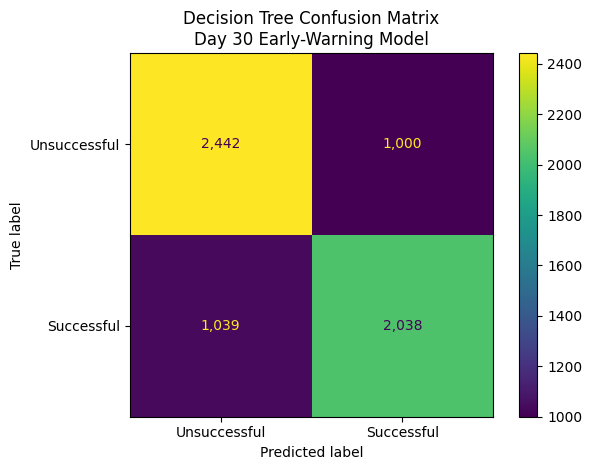

In [22]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(
    values_format=",d"
)

plt.title(
    "Decision Tree Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Confusion Matrix Interpretation

The confusion matrix summarizes the Decision Tree classifier's predictions by comparing the predicted outcomes with the actual student outcomes.

- **2,442 unsuccessful students** were correctly classified as unsuccessful.
- **2,038 successful students** were correctly classified as successful.
- **1,000 unsuccessful students** were incorrectly predicted to be successful.
- **1,039 successful students** were incorrectly predicted to be unsuccessful.

The Decision Tree correctly classified the majority of students in both outcome classes, but it produced a relatively balanced number of false-positive and false-negative predictions. Compared with the Day 30 Logistic Regression model, the Decision Tree generated more classification errors and demonstrated lower overall predictive performance.

Although the model identified meaningful patterns within the early-course data, the confusion matrix suggests that a single Decision Tree is more susceptible to prediction errors than the Logistic Regression baseline. These findings motivate the evaluation of ensemble tree-based methods, such as Random Forest and XGBoost, which often improve classification accuracy by combining the predictions of multiple decision trees.

## Receiver Operating Characteristic (ROC) Curve

The ROC curve evaluates the Decision Tree classifier's ability to distinguish between successful and unsuccessful students across all possible classification thresholds.

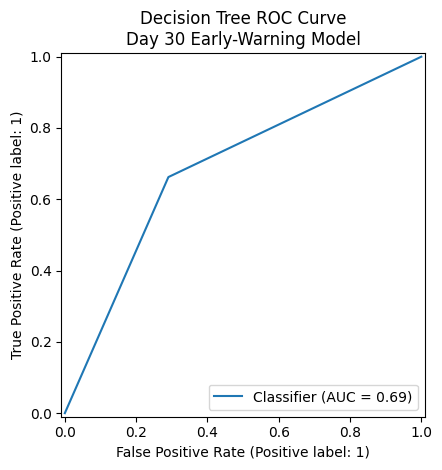

In [23]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Decision Tree ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

## Receiver Operating Characteristic (ROC) Curve Interpretation

The Decision Tree classifier achieved a **ROC-AUC of 0.6859**, indicating moderate discrimination between successful and unsuccessful students using information available during the first 30 days of the course.

Compared with the Day 30 Logistic Regression model (ROC-AUC = **0.8193**), the Decision Tree demonstrated substantially lower discriminative ability. This suggests that the linear logistic regression model generalized more effectively to unseen student data than a single, untuned decision tree.

Although the Decision Tree captured meaningful patterns within the early-warning dataset, its lower ROC-AUC indicates that it was less effective at distinguishing between the two outcome classes. This result highlights one of the primary limitations of individual decision trees and supports the evaluation of ensemble methods, such as Random Forest and XGBoost, which often provide improved predictive performance and greater robustness.

## Feature Importance

Decision Trees estimate the relative importance of each predictor based on how much it reduces classification impurity when used to split the data. Features with higher importance values contribute more to the model's predictions.

In [24]:
feature_names = (
    decision_tree_pipeline.named_steps["preprocessor"]
    .get_feature_names_out()
)

feature_importance = (
    decision_tree_pipeline.named_steps["classifier"]
    .feature_importances_
)

feature_importance_df = (
    pd.DataFrame(
        {
            "Feature": feature_names,
            "Importance": feature_importance
        }
    )
    .sort_values(
        by="Importance",
        ascending=False
    )
)

display(feature_importance_df.head(20))

,Feature,Importance
12,num__last_activity_day,0.181341
18,num__average_score,0.052473
15,num__clicks_per_vle_activity,0.046033
5,num__average_clicks_per_record,0.042735
25,num__first_submission_day,0.040718
13,num__clicks_per_active_day,0.038330
78,cat__code_module_GGG,0.035521
8,num__vle_records,0.034098
9,num__active_days,0.033486
7,num__maximum_clicks_in_record,0.033448


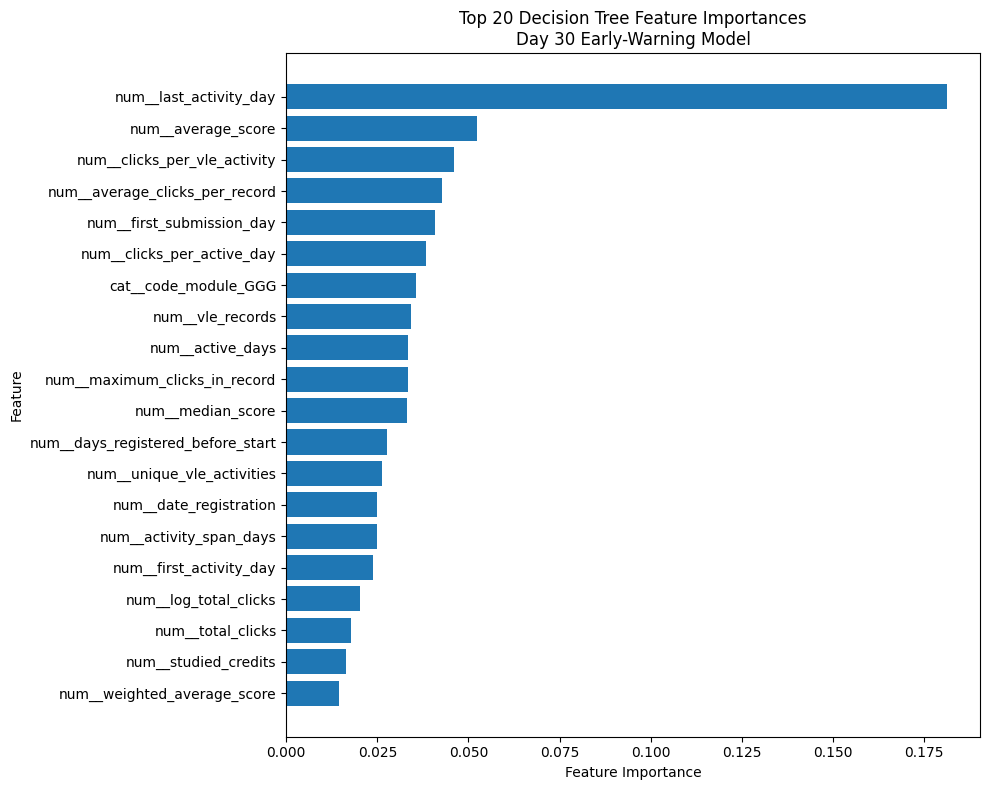

In [25]:
top_features = feature_importance_df.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title(
    "Top 20 Decision Tree Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()
plt.show()

In [26]:
feature_importance_df.to_csv(
    OUTPUT_DIR / "decision_tree_feature_importance.csv",
    index=False
)

print("Feature importance saved.")

Feature importance saved.


## Feature Importance Interpretation

The Decision Tree model identified **`last_activity_day`** as the single most influential predictor of student success during the first 30 days of the course. This finding suggests that recent engagement with the virtual learning environment is a strong indicator of whether a student is likely to complete the course successfully.

Several additional engagement measures—including **average clicks per record**, **clicks per VLE activity**, **clicks per active day**, **VLE records**, **active days**, **maximum clicks in a record**, **unique VLE activities**, and **total clicks**—also ranked among the most important predictors. These results indicate that both the quantity and consistency of student interaction with course materials contribute meaningfully to early prediction.

Assessment-related variables, including **average score**, **median score**, **weighted average score**, and **first submission day**, were also highly influential. These findings suggest that students who perform well on early assessments and begin submitting coursework earlier tend to have a greater likelihood of successfully completing the course.

Registration timing and course characteristics, such as **days registered before the course start**, **registration date**, and the **GGG course module**, also contributed to the model's predictions, although their influence was smaller than the primary engagement and assessment measures.

Overall, the feature importance analysis indicates that the Decision Tree relies primarily on early behavioral engagement and assessment performance when predicting student success. While these predictors are informative, the Decision Tree demonstrated lower predictive performance than the Day 30 Logistic Regression model, suggesting that a single tree may not capture the complex relationships among these variables as effectively. Subsequent analyses using ensemble methods, including Random Forest and XGBoost, will evaluate whether combining multiple decision trees improves predictive performance.

## Save the Trained Model

The trained Decision Tree classifier is saved for future prediction, evaluation, and comparison with other machine learning models.

In [27]:
MODEL_PATH = MODEL_DIR / "decision_tree_early_warning_day30.joblib"

joblib.dump(
    decision_tree_pipeline,
    MODEL_PATH
)

print("Model saved to:")
print(MODEL_PATH)

Model saved to:
/content/drive/MyDrive/SEAID_Framework/models/decision_tree_early_warning_day30.joblib


## Save Evaluation Results

The model evaluation metrics and feature importance values are saved for later comparison with the Logistic Regression, Random Forest, and XGBoost models.

In [28]:
metrics_df.to_csv(
    OUTPUT_DIR / "decision_tree_early_warning_metrics.csv",
    index=False
)

classification_report_df.to_csv(
    OUTPUT_DIR / "decision_tree_classification_report.csv"
)

feature_importance_df.to_csv(
    OUTPUT_DIR / "decision_tree_feature_importance.csv",
    index=False
)

print("Evaluation outputs saved.")

Evaluation outputs saved.


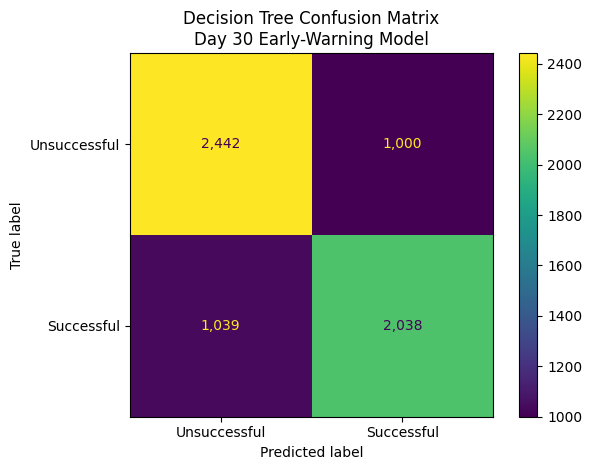

In [29]:
ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix_values,
    display_labels=[
        "Unsuccessful",
        "Successful"
    ]
).plot(values_format=",d")

plt.title(
    "Decision Tree Confusion Matrix\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "decision_tree_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

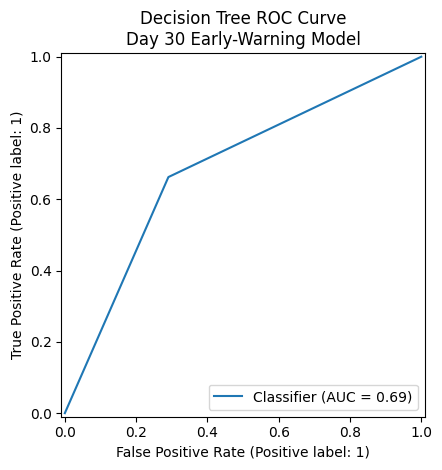

In [30]:
RocCurveDisplay.from_predictions(
    y_test,
    y_prob
)

plt.title(
    "Decision Tree ROC Curve\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "decision_tree_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

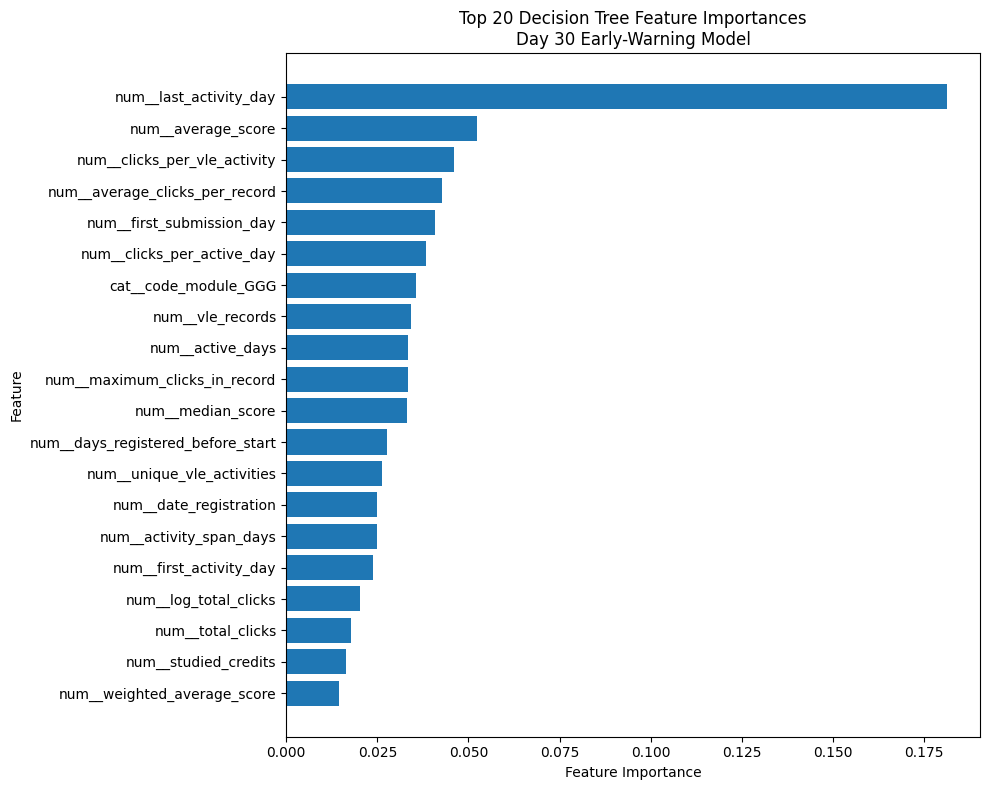

In [31]:
plt.figure(figsize=(10,8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.title(
    "Top 20 Decision Tree Feature Importances\nDay 30 Early-Warning Model"
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR /
    "decision_tree_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Notebook Summary

This notebook developed and evaluated a Decision Tree classifier using the Day 30 early-warning dataset. The model was trained using only information available during the first 30 days of the course, allowing it to simulate a realistic early-warning prediction scenario.

## Model Performance

| Metric | Value |
|:--------|------:|
| Accuracy | **68.7%** |
| Precision | **67.1%** |
| Recall | **66.2%** |
| F1 Score | **66.7%** |
| ROC-AUC | **0.6859** |

## Interpretation

The Decision Tree classifier demonstrated moderate predictive performance using early-course engagement, assessment, registration, and demographic information. The model relied heavily on measures of student engagement—particularly **last activity day**—along with early assessment performance when predicting student success.

Although the Decision Tree captured meaningful nonlinear relationships within the data, it performed below the Day 30 Logistic Regression baseline across all evaluation metrics. This suggests that a single untuned Decision Tree was more susceptible to overfitting and generalized less effectively to unseen student data.

## Next Steps

The next notebook will evaluate a Random Forest classifier using the same Day 30 dataset. By combining the predictions of many decision trees, the Random Forest model may improve predictive accuracy, reduce overfitting, and provide a more robust early-warning model for student success prediction.

# Temporal Decision Tree Early-Warning Evaluation

This section applies the same Decision Tree modeling pipeline to the Day 7, Day 14, Day 21, and Day 30 datasets. Holding the data split and model settings constant allows performance to be compared fairly across early-warning checkpoints.

In [34]:
from pathlib import Path

PROJECT_DIR = Path(
    "/content/drive/MyDrive/SEAID_Framework"
)

PROCESSED_DATA_DIR = (
    PROJECT_DIR / "data" / "processed"
)

MODELS_DIR = (
    PROJECT_DIR / "models"
)

FIGURES_DIR = (
    PROJECT_DIR / "figures"
)

MODELS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed data:", PROCESSED_DATA_DIR)
print("Models:", MODELS_DIR)
print("Figures:", FIGURES_DIR)

Processed data: /content/drive/MyDrive/SEAID_Framework/data/processed
Models: /content/drive/MyDrive/SEAID_Framework/models
Figures: /content/drive/MyDrive/SEAID_Framework/figures


In [35]:
TEMPORAL_DATASETS = {
    7: PROCESSED_DATA_DIR / "early_warning_day7_dataset.csv",
    14: PROCESSED_DATA_DIR / "early_warning_day14_dataset.csv",
    21: PROCESSED_DATA_DIR / "early_warning_day21_dataset.csv",
    30: PROCESSED_DATA_DIR / "early_warning_day30_dataset.csv"
}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():
    print(
        f"Day {checkpoint_day}: "
        f"{dataset_path.name} | "
        f"Exists: {dataset_path.exists()}"
    )

Day 7: early_warning_day7_dataset.csv | Exists: True
Day 14: early_warning_day14_dataset.csv | Exists: True
Day 21: early_warning_day21_dataset.csv | Exists: True
Day 30: early_warning_day30_dataset.csv | Exists: True


In [36]:
temporal_results = []
temporal_models = {}

for checkpoint_day, dataset_path in TEMPORAL_DATASETS.items():

    print(f"\nTraining Day {checkpoint_day} Decision Tree...")

    checkpoint_df = pd.read_csv(dataset_path)

    columns_to_exclude = [
        "target_success",
        "checkpoint_day",
        "final_result",
        "id_student",
        "code_module",
        "code_presentation",
        "withdrew",
        "early_withdrawal",
        "date_unregistration",
        "days_until_withdrawal"
    ]

    columns_to_exclude = [
        column
        for column in columns_to_exclude
        if column in checkpoint_df.columns
    ]

    X_checkpoint = checkpoint_df.drop(
        columns=columns_to_exclude
    )

    y_checkpoint = checkpoint_df[
        "target_success"
    ].astype(int)

    X_checkpoint = X_checkpoint.replace(
        [np.inf, -np.inf],
        np.nan
    )

    (
        X_train_checkpoint,
        X_test_checkpoint,
        y_train_checkpoint,
        y_test_checkpoint
    ) = train_test_split(
        X_checkpoint,
        y_checkpoint,
        test_size=0.20,
        random_state=42,
        stratify=y_checkpoint
    )

    checkpoint_pipeline = Pipeline([
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_split=20,
                min_samples_leaf=10,
                random_state=42
            )
        )
    ])

    checkpoint_pipeline.fit(
        X_train_checkpoint,
        y_train_checkpoint
    )

    checkpoint_predictions = checkpoint_pipeline.predict(
        X_test_checkpoint
    )

    checkpoint_probabilities = (
        checkpoint_pipeline.predict_proba(
            X_test_checkpoint
        )[:, 1]
    )

    checkpoint_confusion = confusion_matrix(
        y_test_checkpoint,
        checkpoint_predictions
    )

    true_negative = checkpoint_confusion[0, 0]
    false_positive = checkpoint_confusion[0, 1]
    false_negative = checkpoint_confusion[1, 0]
    true_positive = checkpoint_confusion[1, 1]

    unsuccessful_recall = (
        true_negative /
        (true_negative + false_positive)
        if (true_negative + false_positive) > 0
        else np.nan
    )

    temporal_results.append({
        "Model": "Decision Tree",
        "Checkpoint Day": checkpoint_day,
        "Students": len(checkpoint_df),
        "Features": X_checkpoint.shape[1],
        "Accuracy": accuracy_score(
            y_test_checkpoint,
            checkpoint_predictions
        ),
        "Precision - Successful": precision_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "Recall - Successful": recall_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "Recall - Unsuccessful": unsuccessful_recall,
        "F1 Score": f1_score(
            y_test_checkpoint,
            checkpoint_predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test_checkpoint,
            checkpoint_probabilities
        ),
        "At-Risk Students Missed": false_positive,
        "Successful Students Flagged": false_negative
    })

    temporal_models[
        checkpoint_day
    ] = checkpoint_pipeline

    print(
        f"Day {checkpoint_day} complete | "
        f"Accuracy: "
        f"{accuracy_score(y_test_checkpoint, checkpoint_predictions):.4f} | "
        f"ROC-AUC: "
        f"{roc_auc_score(y_test_checkpoint, checkpoint_probabilities):.4f}"
    )


Training Day 7 Decision Tree...
Day 7 complete | Accuracy: 0.6791 | ROC-AUC: 0.7424

Training Day 14 Decision Tree...
Day 14 complete | Accuracy: 0.6897 | ROC-AUC: 0.7589

Training Day 21 Decision Tree...
Day 21 complete | Accuracy: 0.7204 | ROC-AUC: 0.7898

Training Day 30 Decision Tree...
Day 30 complete | Accuracy: 0.7446 | ROC-AUC: 0.8203


In [37]:
decision_tree_temporal_results_df = pd.DataFrame(
    temporal_results
)

decision_tree_temporal_results_df = (
    decision_tree_temporal_results_df
    .sort_values("Checkpoint Day")
    .reset_index(drop=True)
)

metric_columns = [
    "Accuracy",
    "Precision - Successful",
    "Recall - Successful",
    "Recall - Unsuccessful",
    "F1 Score",
    "ROC-AUC"
]

decision_tree_temporal_results_df[
    metric_columns
] = decision_tree_temporal_results_df[
    metric_columns
].round(4)

decision_tree_temporal_results_df

,Model,Checkpoint Day,Students,Features,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Successful Students Flagged
0,Decision Tree,7,32593,72,0.6791,0.6477,0.7020,0.6586,0.6737,0.7424,1175,917
1,Decision Tree,14,32593,72,0.6897,0.6678,0.6815,0.6970,0.6746,0.7589,1043,980
2,Decision Tree,21,32593,72,0.7204,0.6822,0.7631,0.6822,0.7204,0.7898,1094,729
3,Decision Tree,30,32593,72,0.7446,0.7038,0.7923,0.7019,0.7455,0.8203,1026,639


In [38]:
decision_tree_temporal_summary = (
    decision_tree_temporal_results_df[
        [
            "Model",
            "Checkpoint Day",
            "Accuracy",
            "Precision - Successful",
            "Recall - Successful",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed"
        ]
    ]
    .copy()
)

decision_tree_temporal_summary[
    "Checkpoint"
] = decision_tree_temporal_summary[
    "Checkpoint Day"
].apply(
    lambda day: f"Day {int(day)}"
)

decision_tree_temporal_summary = (
    decision_tree_temporal_summary.drop(
        columns="Checkpoint Day"
    )
)

decision_tree_temporal_summary

,Model,Accuracy,Precision - Successful,Recall - Successful,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed,Checkpoint
0,Decision Tree,0.6791,0.6477,0.7020,0.6586,0.6737,0.7424,1175,Day 7
1,Decision Tree,0.6897,0.6678,0.6815,0.6970,0.6746,0.7589,1043,Day 14
2,Decision Tree,0.7204,0.6822,0.7631,0.6822,0.7204,0.7898,1094,Day 21
3,Decision Tree,0.7446,0.7038,0.7923,0.7019,0.7455,0.8203,1026,Day 30


In [39]:
DECISION_TREE_RESULTS_PATH = (
    PROCESSED_DATA_DIR /
    "decision_tree_temporal_results.csv"
)

DECISION_TREE_SUMMARY_PATH = (
    PROCESSED_DATA_DIR /
    "decision_tree_temporal_summary.csv"
)

decision_tree_temporal_results_df.to_csv(
    DECISION_TREE_RESULTS_PATH,
    index=False
)

decision_tree_temporal_summary.to_csv(
    DECISION_TREE_SUMMARY_PATH,
    index=False
)

print("Saved detailed results:")
print(DECISION_TREE_RESULTS_PATH)

print("\nSaved temporal comparison:")
print(DECISION_TREE_SUMMARY_PATH)

Saved detailed results:
/content/drive/MyDrive/SEAID_Framework/data/processed/decision_tree_temporal_results.csv

Saved temporal comparison:
/content/drive/MyDrive/SEAID_Framework/data/processed/decision_tree_temporal_summary.csv


In [40]:
for checkpoint_day, model in temporal_models.items():

    checkpoint_model_path = (
        MODELS_DIR /
        f"decision_tree_day{checkpoint_day}.joblib"
    )

    joblib.dump(
        model,
        checkpoint_model_path
    )

    print(
        f"Saved Day {checkpoint_day} model: "
        f"{checkpoint_model_path}"
    )

Saved Day 7 model: /content/drive/MyDrive/SEAID_Framework/models/decision_tree_day7.joblib
Saved Day 14 model: /content/drive/MyDrive/SEAID_Framework/models/decision_tree_day14.joblib
Saved Day 21 model: /content/drive/MyDrive/SEAID_Framework/models/decision_tree_day21.joblib
Saved Day 30 model: /content/drive/MyDrive/SEAID_Framework/models/decision_tree_day30.joblib


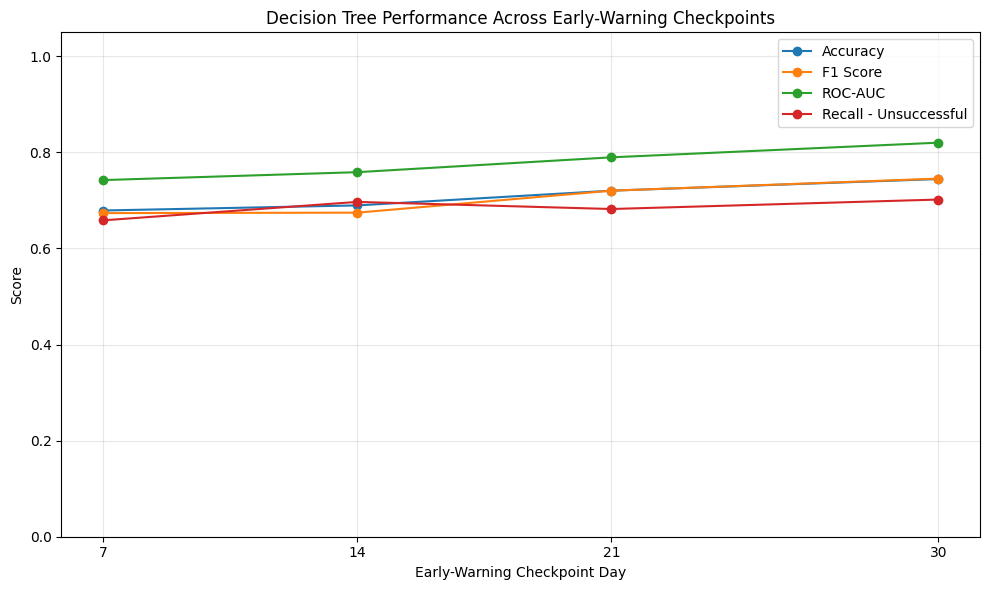

Saved performance plot:
/content/drive/MyDrive/SEAID_Framework/figures/decision_tree_temporal_performance.png


In [41]:
plt.figure(figsize=(10, 6))

for metric in [
    "Accuracy",
    "F1 Score",
    "ROC-AUC",
    "Recall - Unsuccessful"
]:
    plt.plot(
        decision_tree_temporal_results_df[
            "Checkpoint Day"
        ],
        decision_tree_temporal_results_df[
            metric
        ],
        marker="o",
        label=metric
    )

plt.xlabel("Early-Warning Checkpoint Day")
plt.ylabel("Score")

plt.title(
    "Decision Tree Performance Across "
    "Early-Warning Checkpoints"
)

plt.xticks([7, 14, 21, 30])
plt.ylim(0, 1.05)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

DECISION_TREE_FIGURE_PATH = (
    FIGURES_DIR /
    "decision_tree_temporal_performance.png"
)

plt.savefig(
    DECISION_TREE_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved performance plot:")
print(DECISION_TREE_FIGURE_PATH)

In [42]:
LOGISTIC_RESULTS_PATH = (
    PROCESSED_DATA_DIR /
    "logistic_regression_temporal_results.csv"
)

logistic_results_df = pd.read_csv(
    LOGISTIC_RESULTS_PATH
)

logistic_comparison = logistic_results_df[
    [
        "Checkpoint Day",
        "Accuracy",
        "Recall - Unsuccessful",
        "F1 Score",
        "ROC-AUC",
        "At-Risk Students Missed"
    ]
].copy()

logistic_comparison["Model"] = (
    "Logistic Regression"
)

decision_tree_comparison = (
    decision_tree_temporal_results_df[
        [
            "Checkpoint Day",
            "Accuracy",
            "Recall - Unsuccessful",
            "F1 Score",
            "ROC-AUC",
            "At-Risk Students Missed"
        ]
    ]
    .copy()
)

decision_tree_comparison["Model"] = (
    "Decision Tree"
)

model_comparison_df = pd.concat(
    [
        logistic_comparison,
        decision_tree_comparison
    ],
    ignore_index=True
)

model_comparison_df = model_comparison_df[
    [
        "Model",
        "Checkpoint Day",
        "Accuracy",
        "Recall - Unsuccessful",
        "F1 Score",
        "ROC-AUC",
        "At-Risk Students Missed"
    ]
]

model_comparison_df.sort_values(
    [
        "Checkpoint Day",
        "Model"
    ]
)

,Model,Checkpoint Day,Accuracy,Recall - Unsuccessful,F1 Score,ROC-AUC,At-Risk Students Missed
4,Decision Tree,7,0.6791,0.6586,0.6737,0.7424,1175
0,Logistic Regression,7,0.6970,0.6886,0.6876,0.7698,1072
5,Decision Tree,14,0.6897,0.6970,0.6746,0.7589,1043
1,Logistic Regression,14,0.7090,0.6923,0.7024,0.7844,1059
6,Decision Tree,21,0.7204,0.6822,0.7204,0.7898,1094
2,Logistic Regression,21,0.7271,0.7150,0.7193,0.8056,981
7,Decision Tree,30,0.7446,0.7019,0.7455,0.8203,1026
3,Logistic Regression,30,0.7354,0.7147,0.7302,0.8193,982
